In [6]:
import pandas as pd
import numpy as np

# Sample data
data = {
    "Cabin": [np.nan, "C85", np.nan, "C123", np.nan],
    "Ticket": ["A/5 21171", "PC 17599", "STON/O2. 3101282", "113803", "373450"],
    "number": ["5", "3", "6", "3", "A"],  # mixed numeric/categorical
    "Survived": [0, 1, 1, 1, 0]
}

df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)


Original DataFrame:
  Cabin            Ticket number  Survived
0   NaN         A/5 21171      5         0
1   C85          PC 17599      3         1
2   NaN  STON/O2. 3101282      6         1
3  C123            113803      3         1
4   NaN            373450      A         0


In [8]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [9]:
df.unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [10]:
df['number'].unique()

array(['5', '3', '6', 'A'], dtype=object)

In [12]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')

In [14]:
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [16]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450'],
      dtype=object)

In [19]:
df['cabin_num'] = df['Cabin'].str.extract(r'(\d+)')

In [21]:
df['cabin_cat'] = df['Cabin'].str[0]

In [23]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

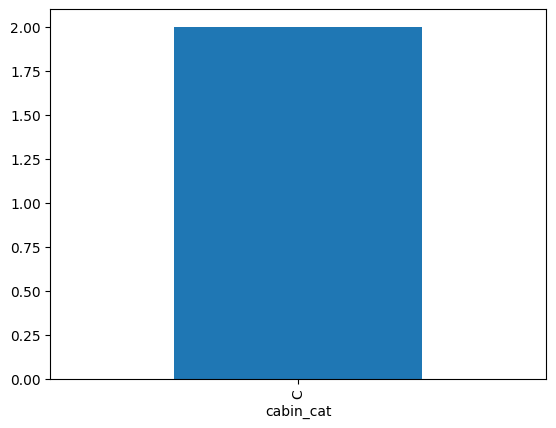

In [24]:
df['cabin_cat'].value_counts().plot(kind='bar')